In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

b = np.load('rmd17_ethanol.npz')
print(b['nuclear_charges'])


[6 6 8 1 1 1 1 1 1]


In [ ]:
all_coords = b['coords']
all_energies = b['energies']

print(all_coords.shape)
print(all_energies.shape)

N = len(all_coords)
 
perm = np.random.permutation(N)

coords = all_coords[perm[:2000]]        
energies = all_energies[perm[:2000]]

print(coords.shape)
print(energies.shape)


(100000, 9, 3)
(100000,)
(2000, 9, 3)
(2000,)


In [3]:
bonds = [(0,1), (0,3), (0,4), (0,5), (1,2), (1,6), (1,7), (2,8)]

def bond_lengths(coords):
    lengths = []
    for i in range(len(coords)):
        for a,b in bonds:
            length = np.linalg.norm(coords[i,a,:]-coords[i,b,:])

            lengths.append(length)
    return(lengths)

ben_lengths = np.array(bond_lengths(coords))
BL = ben_lengths.reshape(len(coords), len(bonds))
print(BL)
print(BL.shape)

[[1.46386054 1.16416097 1.21646643 ... 1.15829765 1.14195076 0.96524321]
 [1.56992332 1.06273688 1.1252861  ... 1.16810702 1.093196   0.87076752]
 [1.5350311  1.08509427 1.16050421 ... 1.10327502 1.10616226 1.02236549]
 ...
 [1.43353125 1.10773629 1.16031642 ... 1.07576685 1.13083689 0.96681267]
 [1.58083648 1.07156827 1.08736262 ... 1.09184259 1.09385699 0.98099279]
 [1.62815367 1.07440614 1.09185601 ... 1.11129437 1.12776435 1.00459201]]
(2000, 8)


In [4]:
angles = [(1, 0, 3), (1, 0, 4), (1, 0, 5), (3, 0, 4), (3, 0, 5), (4, 0, 5), (0, 1, 2), (0, 1, 6), (0, 1, 7),   
(2, 1, 6), (2, 1, 7), (6, 1, 7), (1, 2, 8)]

def bond_angles(coords):
    ben_angles = []
    for o in range(len(coords)):
        for i,j,k in angles:
            length1 = np.linalg.norm(coords[o,i,:]-coords[o,j,:])
            length2 = np.linalg.norm(coords[o,k,:]-coords[o,j,:])


            dot_prod = np.dot((coords[o,i,:]-coords[o,j,:]),(coords[o,k,:]-coords[o,j,:]))


            cosang = dot_prod / (length1 * length2)


            ben_angles.append(np.acos(cosang))
    return(ben_angles)


benz_angles = np.array(bond_angles(coords))
AN = benz_angles.reshape(len(coords), len(angles))
print(AN)
print(AN.shape)

[[1.95975358 1.87751546 0.48276506 ... 1.43893363 1.84660159 2.56940045]
 [2.04899079 1.85781487 0.55490108 ... 1.74702279 2.00735168 1.63102028]
 [1.81620665 1.73268683 0.59053383 ... 1.91212275 1.82996679 1.31670305]
 ...
 [1.89546531 1.94920328 0.49374514 ... 1.53560233 1.86485222 2.3872871 ]
 [2.1324325  1.8599315  0.4077144  ... 1.75946394 1.75083157 2.54256667]
 [1.8301522  1.88334605 0.51996674 ... 1.56622532 1.86585607 1.87086775]]
(2000, 13)


In [5]:
X = np.concatenate((BL,AN), axis=1)
y = np.array(energies)


print(X)
print(y)
print(X.shape)
print(y.shape)

[[1.46386054 1.16416097 1.21646643 ... 1.43893363 1.84660159 2.56940045]
 [1.56992332 1.06273688 1.1252861  ... 1.74702279 2.00735168 1.63102028]
 [1.5350311  1.08509427 1.16050421 ... 1.91212275 1.82996679 1.31670305]
 ...
 [1.43353125 1.10773629 1.16031642 ... 1.53560233 1.86485222 2.3872871 ]
 [1.58083648 1.07156827 1.08736262 ... 1.75946394 1.75083157 2.54256667]
 [1.62815367 1.07440614 1.09185601 ... 1.56622532 1.86585607 1.87086775]]
[-97074.8452293  -97072.12904474 -97075.14871172 ... -97083.53494562
 -97070.57820919 -97077.99228596]
(2000, 21)
(2000,)


In [6]:
mu_X = X.mean(axis=0)
std_X = X.std(axis=0)

X_new = (X - mu_X)/ std_X

mu_y = y.mean()
std_y = y.std()

y_new = (y - mu_y)/ std_y

print(y_new)

[ 0.27871978  0.92653444  0.2063387  ... -1.79379242  1.29641137
 -0.47185861]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print(y_train_t.shape)

torch.Size([1600, 1])


In [8]:
class Model(nn.Module):
    
    def __init__(self, input_features = 21, hidden1 = 64, hidden2 = 32, hidden3 = 16, output_features = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1) 
        self.fc2 = nn.Linear(hidden1, hidden2) 
        self.fc3 = nn.Linear(hidden2, hidden3) 
        self.fc4 = nn.Linear(hidden3, output_features)
        self.ac1 = nn.SiLU()
        self.ac2 = nn.SiLU()
        self.ac3 = nn.SiLU()

    def forward(self, x):
        x = self.fc1(x) 
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x) 
        x = self.fc3(x)
        x = self.ac3(x)
        x = self.fc4(x) 
        return x

In [ ]:
epochs = 200
losses = []

torch.manual_seed(42)
model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay = 1e-3)

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train_t) 
    loss = criterion(y_pred, y_train_t)    
    losses.append(loss.item()) 


    if epoch%10==0:
        print(f'Epoch: {epoch} and loss: {loss}') 

    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step() 

Epoch: 0 and loss: 1.0351775884628296
Epoch: 10 and loss: 1.0274097919464111
Epoch: 20 and loss: 1.019423007965088
Epoch: 30 and loss: 1.0107327699661255
Epoch: 40 and loss: 1.000819444656372
Epoch: 50 and loss: 0.9891211986541748
Epoch: 60 and loss: 0.9751094579696655
Epoch: 70 and loss: 0.9584037661552429
Epoch: 80 and loss: 0.9388476610183716
Epoch: 90 and loss: 0.9165033102035522
Epoch: 100 and loss: 0.8915403485298157
Epoch: 110 and loss: 0.864095151424408
Epoch: 120 and loss: 0.8341505527496338
Epoch: 130 and loss: 0.8015658855438232
Epoch: 140 and loss: 0.7663100957870483
Epoch: 150 and loss: 0.7287180423736572
Epoch: 160 and loss: 0.689597487449646
Epoch: 170 and loss: 0.650003969669342
Epoch: 180 and loss: 0.6108408570289612
Epoch: 190 and loss: 0.5726542472839355
Epoch: 200 and loss: 0.5358200073242188
Epoch: 210 and loss: 0.5007891058921814
Epoch: 220 and loss: 0.4680759906768799
Epoch: 230 and loss: 0.438130646944046
Epoch: 240 and loss: 0.4112214744091034
Epoch: 250 and lo

C:\Users\home\AppData\Local\Temp\ipykernel_10692\1804017874.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


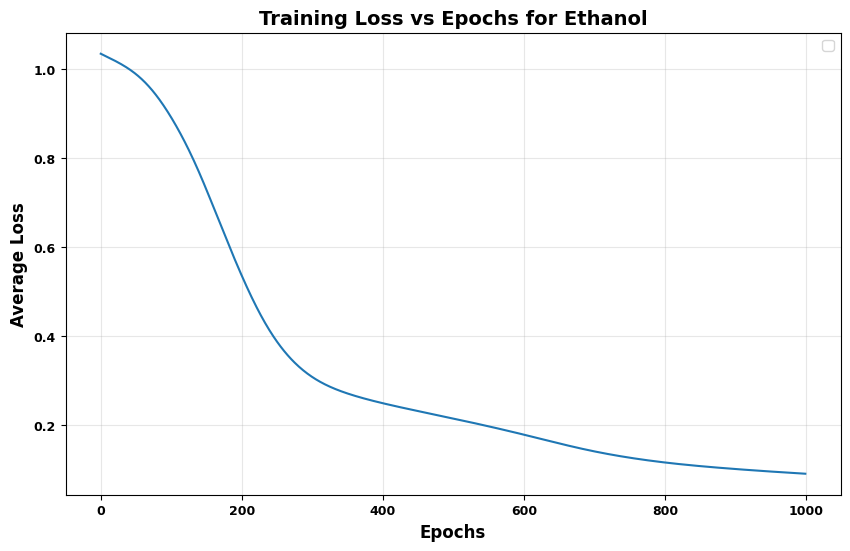

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Average Loss', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig('NNTrain_loss_vs_epoch_ethanol.png')
plt.title('Training Loss vs Epochs for Ethanol', fontsize=14, fontweight='bold')
plt.show()

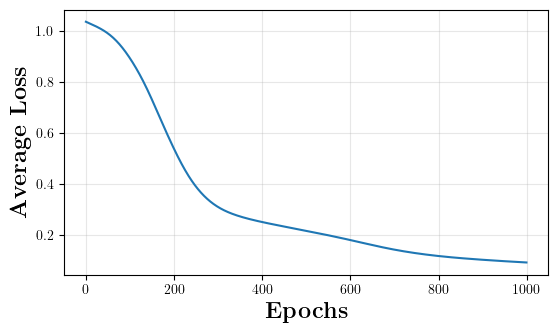

In [ ]:
import matplotlib as mpl

mpl.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"], "axes.labelsize": 17,
    "font.size": 17, "legend.fontsize": 13, "xtick.labelsize": 13, "ytick.labelsize": 13})

def set_size(width_pt, fraction=1):
    inches_per_pt = 1/72.27
    golden_ratio = (5**0.5 - 1)/2
    width_in = width_pt * inches_per_pt * fraction
    height_in = width_in * golden_ratio
    return (width_in, height_in)

fig = plt.figure(figsize=set_size(426))

plt.plot(losses, label='Training Loss')
plt.xlabel(r'\textbf{Epochs}')
plt.ylabel(r'\textbf{Average Loss}')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('NN_Ethanol_Loss.pdf')
plt.show()

In [12]:
model.eval()
with torch.no_grad():
    final_test_pred = model(X_test_t)
    final_test_loss = nn.MSELoss()
    loss = final_test_loss(final_test_pred, y_test_t)
print("final test loss:", float(loss))

pred_unnormalized = final_test_pred.numpy().squeeze() * std_y + mu_y
true_unnormalized = y_test_t.numpy().squeeze() * std_y + mu_y

final test loss: 0.2633049786090851


In [13]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(true_unnormalized, pred_unnormalized)
mae = mean_absolute_error(true_unnormalized, pred_unnormalized)
mse = mean_squared_error(true_unnormalized, pred_unnormalized)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")  
print(f"MAE: {mae:.4f}")      
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7232
MAE: 1.6557
RMSE: 2.1515


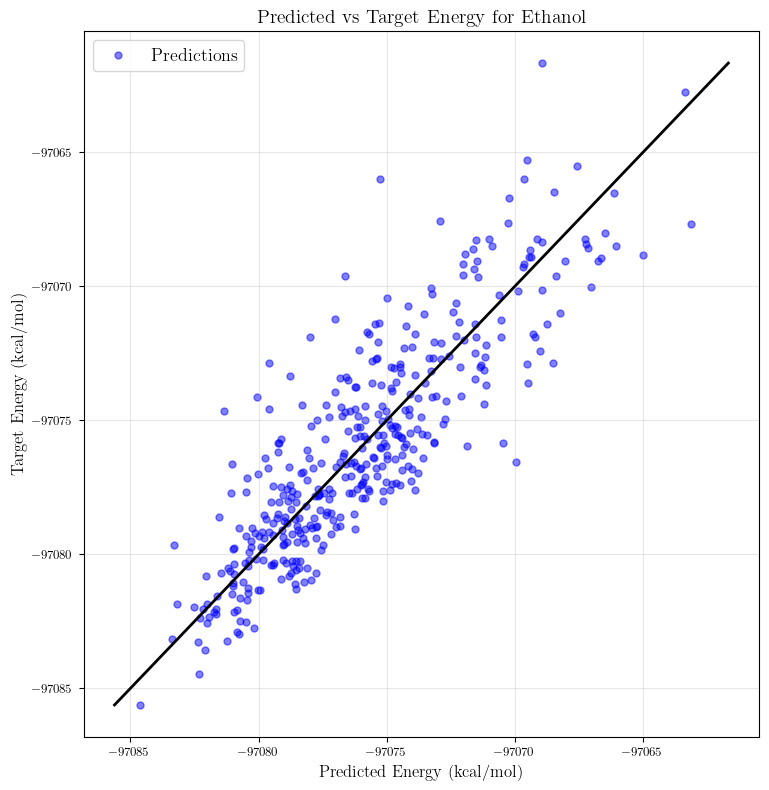

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], [true_unnormalized.min(), true_unnormalized.max()], 'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Predicted Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.ylabel('Target Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.tight_layout()
#plt.savefig('NNNtarget_vs_predE_ethanol.png')
plt.title('Predicted vs Target Energy for Ethanol', fontsize=14, fontweight='bold')
plt.show()


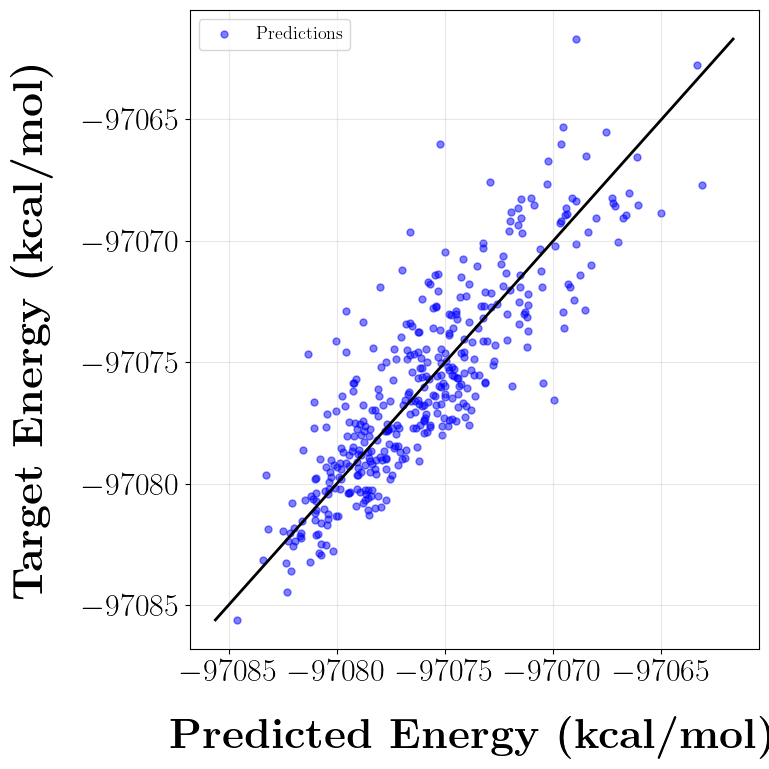

: 

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], [true_unnormalized.min(), true_unnormalized.max()],'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel(r'\textbf{Predicted Energy (kcal/mol)}', fontsize=31, labelpad=21)
plt.ylabel(r'\textbf{Target Energy (kcal/mol)}', fontsize=31, labelpad=21)
plt.xticks(fontsize=23)
plt.yticks(fontsize=23)
plt.tight_layout()
#plt.savefig('NN_Ethanol_Scatter.pdf', bbox_inches='tight')
plt.show()